In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import seaborn as sns

In [ ]:
df = pd.read_csv('Data/fit_data.csv')
df = (
    df.query("solvent_name in ['Water','Methanol','ethanol']")
)

df

,DOI,solvent_name,solvent,zn_source,zn_source_mmol,hmim_mmol,stirring,temperature_C,time_min,size_nm,additive,ratio,counterion,zn_source_mM,hmim_mM,Verify
0,10.1021/acsami.9b23314,Methanol,499.375780,Zn(NO3)2·6H2O,0.537869,4.993910,Yes,50,180.0,48.0,not given,0.107705,NO3-,0.001077,0.010000,True
1,10.1039/c7nr07949d,Water,1111.111111,Zn(NO3)2·6H2O,0.050425,0.304507,No,0,30.0,250.0,not given,0.165597,NO3-,0.000045,0.000274,True
2,10.1039/c3ce27093a,Water,3333.333333,Zn(NO3)2·6H2O,6.084647,12.180268,Yes,21,10.0,300.0,Pluronic P123,0.499550,NO3-,0.001825,0.003654,True
3,10.1039/c3ce27093a,Water,3333.333333,Zn(NO3)2·6H2O,6.084647,12.180268,Yes,21,10.0,300.0,Pluronic P123,0.499550,NO3-,0.001825,0.003654,True
4,10.1039/c3ce27093a,Water,3333.333333,Zn(NO3)2·6H2O,6.084647,12.180268,Yes,21,60.0,300.0,Pluronic P123,0.499550,NO3-,0.001825,0.003654,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,10.1002/cjce.23155,Methanol,494.382000,Zn(NO3)2·6H2O,1.000000,4.000000,No,80,6.0,43.0,-,0.250000,NO3-,0.002023,0.008091,True
187,10.1002/cjce.23155,Methanol,494.382000,Zn(NO3)2·6H2O,1.000000,4.000000,No,120,6.0,48.0,-,0.250000,NO3-,0.002023,0.008091,True
188,10.1002/cjce.23155,Methanol,494.382000,Zn(NO3)2·6H2O,1.000000,4.000000,No,150,6.0,52.0,-,0.250000,NO3-,0.002023,0.008091,True
189,10.1016/j.micromeso.2020.110761,Methanol,1235.955000,Zn(NO3)2·6H2O,2.464000,19.817000,Yes,25,1440.0,45.0,-,0.124338,NO3-,0.001994,0.016034,True


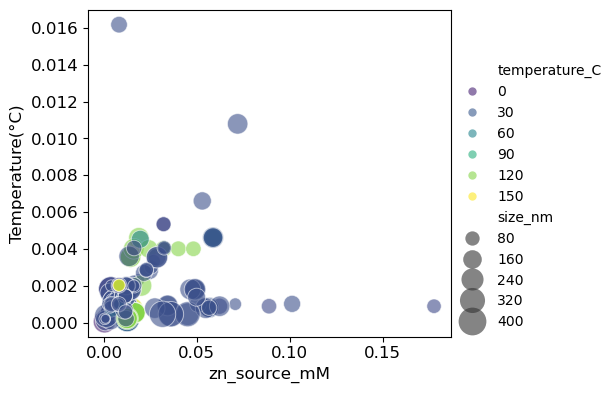

In [ ]:
g = sns.relplot(x="hmim_mM", y="zn_source_mM", hue="temperature_C", size="size_nm",
            sizes=(40, 400), alpha=.6, palette="viridis",aspect=1.2,
            height=4, data=df)
# g = sns.relplot(x="zn_source_mmol", y="hmim_mmol", hue="solvent_name", size="size_nm",
#             sizes=(40, 400), alpha=.6, palette="colorblind",aspect=1.2,
#             height=4, data=df)
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
ax = g.ax
#ax.set_xlim(-0.05,0.6)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_xlabel('zn_source_mM',fontsize=12)
ax.set_ylabel('Temperature(°C)',fontsize=12)
ax.tick_params(axis='both',which='major',labelsize=12)
# hb = ax.hexbin(df['temperature_C'], df['ratio'], 
#                gridsize=20, 
#                cmap='BuGn',      
#                mincnt=1,         
#                edgecolors='none', 
#                alpha=1)  
# cb = fig.colorbar(hb, ax=ax, shrink=0.6, label='Point Density')
#g.savefig('FIG/relplot.pdf')


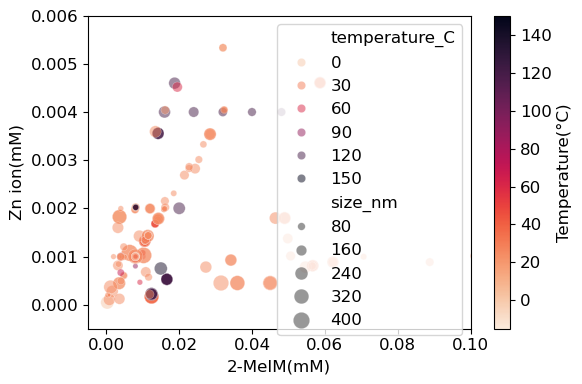

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.size': 12})

fig, ax = plt.subplots(figsize=(6, 4))

scatter = sns.scatterplot(
    data=df,
    x="hmim_mM",
    y="zn_source_mM",
    hue="temperature_C",      
    size="size_nm",     
    sizes=(5, 140),
    palette="rocket_r", 
    alpha=0.5,
    ax=ax,
    legend=True       
)


for spine in ['top', 'right']:
    ax.spines[spine].set_visible(True)


ax.set_xlabel('2-MeIM(mM)')
ax.set_ylabel('Zn ion(mM)')
ax.set_ylim(-0.0005,0.006)
ax.set_xlim(-0.005,0.1)
# 地道地添加 Colorbar
# 我们直接从 scatter 对象中获取颜色映射信息
norm = plt.Normalize(df['temperature_C'].min(), df['temperature_C'].max())
sm = plt.cm.ScalarMappable(cmap="rocket_r", norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Temperature(°C)')
fig.savefig('FIG/20260406_1.pdf')
plt.tight_layout()
plt.show()

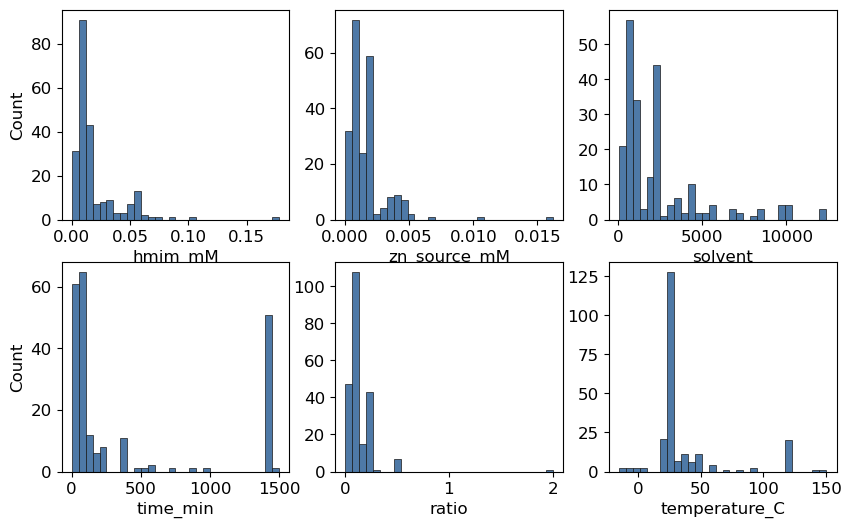

In [19]:
target = ['hmim_mM','zn_source_mM','solvent','time_min','ratio','temperature_C']
plt.rcParams.update({'pdf.fonttype': 42, 'ps.fonttype': 42, 'font.size': 12})

fig =plt.figure(figsize=(10,6))

for i,key in enumerate(target):
    ax = fig.add_subplot(2,3,i+1)
    ax.hist(df[key],bins=30,color='#4E79A7',edgecolor="#171717",lw=0.5)
    ax.set_xlabel(key)  
    if i == 0 or i ==3:
        ax.set_ylabel('Count')

fig.savefig('visualizationsP/hist.pdf')
